# US Industrial Carbon Emissions Retrospective Dashboard (2010–2023)

## Business Problem

This project analyzes 14 years of EPA Greenhouse Gas Reporting Program (GHGRP) data to identify long-term trends, major emitting sectors, geographic patterns, and changes in reporting facilities.

The analysis provides a historical baseline of US industrial greenhouse gas emissions for sustainability-focused analysis.

## Dataset

- **Source:** EPA Greenhouse Gas Reporting Program (GHGRP)
- **Period:** 2010–2023
- **Records:** 94,378 facility-year records
- **Facilities:** 8,778 unique facilities
- **States/Territories:** 54

## Methodology

1. **Excel Inspection:** Checked raw files for header structure and data consistency.
2. **Python Cleaning:** Combined 14 annual files, standardized columns, handled missing values, and flagged zero-emission records.
3. **SQL Analysis:** Performed 5 analytical queries covering national trends, top sectors, top facilities, state rankings, and YoY analysis.
4. **Exploratory Visualization:** Created Matplotlib charts for emissions trends, sectors, states, and facility counts.
5. **Power BI Dashboard:** Built an interactive dashboard to communicate key trends and business insights.

In [ ]:
# ============================================================
# SECTION 1: SETUP & IMPORTS
# ============================================================
# This section loads the tools we need and connects to Google Drive.
# If you're running this locally (not Colab), skip the drive.mount()
# and update DATA_PATH to your local folder.

# --- Python Libraries ---
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import os
import glob

# --- Connect to Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

# --- Folder Paths ---
# DATA_PATH: Where your 14 raw Excel files live
# OUTPUT_PATH: Where we save cleaned data, database, and charts
# CHART_PATH: Subfolder for matplotlib images

DATA_PATH = '/content/drive/MyDrive/EPA_GHGRP_Project/data'
OUTPUT_PATH = '/content/drive/MyDrive/EPA_GHGRP_Project/processed'
CHART_PATH = os.path.join(OUTPUT_PATH, 'charts')

# Create output folders if they don't exist
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(CHART_PATH, exist_ok=True)

print(f"Output folder ready: {OUTPUT_PATH}")
print(f"Chart folder ready:  {CHART_PATH}")

# --- Verify Raw Data Files ---
# Look for all ghgp_data_YYYY.xlsx files (exclude the '_by_year' variant)
files = sorted(glob.glob(f'{DATA_PATH}/ghgp_data_20*.xlsx'))
files = [f for f in files if '_by_year' not in f]

print(f"\n{'='*50}")
print(f"DATA VERIFICATION")
print(f"{'='*50}")
print(f"Found {len(files)} Excel files:")
for f in files:
    print(f"  ✓ {os.path.basename(f)}")

if len(files) != 14:
    print(f"\n WARNING: Expected 14 files (2010-2023), found {len(files)}")
else:
    print(f"\n All 14 years present. Ready to combine.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output folder ready: /content/drive/MyDrive/EPA_GHGRP_Project/processed
Chart folder ready:  /content/drive/MyDrive/EPA_GHGRP_Project/processed/charts

DATA VERIFICATION
Found 14 Excel files:
  ✓ ghgp_data_2010.xlsx
  ✓ ghgp_data_2011.xlsx
  ✓ ghgp_data_2012.xlsx
  ✓ ghgp_data_2013.xlsx
  ✓ ghgp_data_2014.xlsx
  ✓ ghgp_data_2015.xlsx
  ✓ ghgp_data_2016.xlsx
  ✓ ghgp_data_2017.xlsx
  ✓ ghgp_data_2018.xlsx
  ✓ ghgp_data_2019.xlsx
  ✓ ghgp_data_2020.xlsx
  ✓ ghgp_data_2021.xlsx
  ✓ ghgp_data_2022.xlsx
  ✓ ghgp_data_2023.xlsx

 All 14 years present. Ready to combine.


In [ ]:
# ============================================================
# SECTION 2: DATA INGESTION
# ============================================================
# Combine 14 annual EPA GHGRP Excel files (2010-2023)
# Note: First 3 rows are metadata; headers start at row 4 (index 3)

all_data = []

for file in files:
    year = int(os.path.basename(file).replace('ghgp_data_', '').replace('.xlsx', ''))
    df = pd.read_excel(file, skiprows=3)

    if 'REPORTING_YEAR' not in df.columns and 'Reporting Year' not in df.columns:
        df['REPORTING_YEAR'] = year

    all_data.append(df)
    print(f"  {year}: {len(df)} rows")

combined = pd.concat(all_data, ignore_index=True)
print(f"\nCombined: {len(combined):,} rows x {len(combined.columns)} columns")

# Save raw
combined.to_csv(f'{OUTPUT_PATH}/ghgp_all_years_2010_2023_raw.csv', index=False)

  2010: 6297 rows
  2011: 6907 rows
  2012: 7102 rows
  2013: 7191 rows
  2014: 7349 rows
  2015: 7242 rows
  2016: 6572 rows
  2017: 6488 rows
  2018: 6581 rows
  2019: 6580 rows
  2020: 6556 rows
  2021: 6529 rows
  2022: 6514 rows
  2023: 6470 rows

Combined: 94,378 rows x 67 columns


In [ ]:
# ============================================================
# SECTION 3: DATA CLEANING
# ============================================================

# STEP 1: Select only the columns we need for analysis
# The original EPA files have 67 columns — we keep only the essential 13

cols_to_keep = [
    'Facility Id',           # Unique facility identifier
    'Facility Name',         # Facility name
    'City',                  # Location
    'State',                 # Location
    'Zip Code',              # Location
    'Address',               # Location
    'County',                # Location
    'Latitude',              # Map coordinates
    'Longitude',             # Map coordinates
    'Primary NAICS Code',    # Industry classification
    'Industry Type (sectors)',  # Sector name
    'Total reported direct emissions',  # Main metric (metric tons CO2e)
    'REPORTING_YEAR'         # Year (added during ingestion)
]

# Some columns may be missing in certain years — only keep what exists
available_cols = [c for c in cols_to_keep if c in combined.columns]
missing_cols = [c for c in cols_to_keep if c not in combined.columns]

print(f"Columns found: {len(available_cols)}")
print(f"Columns missing (not in all years): {missing_cols if missing_cols else 'None'}")

# Create cleaned dataframe with only available columns
df_clean = combined[available_cols].copy()
# STEP 2: Rename columns to simpler, code-friendly names
rename_map = {
    'Facility Id': 'facility_id',
    'Facility Name': 'facility_name',
    'City': 'city',
    'State': 'state',
    'Zip Code': 'zip_code',
    'Address': 'address',
    'County': 'county',
    'Latitude': 'latitude',
    'Longitude': 'longitude',
    'Primary NAICS Code': 'naics_code',
    'Industry Type (sectors)': 'industry_sector',
    'Total reported direct emissions': 'total_emissions',
    'REPORTING_YEAR': 'reporting_year'
}

df_clean = df_clean.rename(columns={k: v for k, v in rename_map.items() if k in df_clean.columns})

print(f"\nRenamed columns: {df_clean.columns.tolist()}")
# STEP 3: Handle missing values

print("\n--- MISSING VALUES BEFORE CLEANING ---")
print(df_clean.isnull().sum())

# CRITICAL: Drop rows with missing total_emissions
rows_before = len(df_clean)
df_clean = df_clean.dropna(subset=['total_emissions'])
rows_dropped = rows_before - len(df_clean)
print(f"\nDropped {rows_dropped:,} rows with missing total_emissions")

df_clean['facility_name'] = df_clean['facility_name'].fillna('UNKNOWN')
df_clean['state'] = df_clean['state'].fillna('UNKNOWN')
df_clean['industry_sector'] = df_clean['industry_sector'].fillna('Unknown Sector')
df_clean['address'] = df_clean['address'].fillna('Not Reported')
df_clean['county'] = df_clean['county'].fillna('Not Reported')

print("\n--- MISSING VALUES AFTER CLEANING ---")
print(df_clean.isnull().sum())


# STEP 4: Fix data types
# NAICS codes are category labels, not numbers — convert to string to prevent math errors
df_clean['naics_code'] = df_clean['naics_code'].astype(str).str.replace('.0', '', regex=False)

print(f"\nData types fixed. Sample NAICS codes: {df_clean['naics_code'].unique()[:5]}")


# STEP 5: Flag data quality anomalies
df_clean['emissions_flag'] = np.where(df_clean['total_emissions'] == 0, 'ZERO_REPORTED', 'VALID')

print(f"\nData quality flags:")
print(df_clean['emissions_flag'].value_counts())


# STEP 6: Save the cleaned dataset
clean_file = f'{OUTPUT_PATH}/ghgp_cleaned_2010_2023.csv'
df_clean.to_csv(clean_file, index=False, encoding='utf-8')

print(f"\n{'='*50}")
print(f"CLEANING COMPLETE")
print(f"{'='*50}")
print(f"Original rows:  {len(combined):,}")
print(f"Cleaned rows:   {len(df_clean):,}")
print(f"Columns:        {len(df_clean.columns)}")
print(f"Years:          {sorted(df_clean['reporting_year'].unique())}")
print(f"Facilities:     {df_clean['facility_id'].nunique():,}")
print(f"States:         {df_clean['state'].nunique()}")
print(f"File saved:     {clean_file}")
print(f"{'='*50}")

# Preview the cleaned data
print("\nFirst 3 rows of cleaned data:")
display(df_clean.head(3))

Columns found: 13
Columns missing (not in all years): None

Renamed columns: ['facility_id', 'facility_name', 'city', 'state', 'zip_code', 'address', 'county', 'latitude', 'longitude', 'naics_code', 'industry_sector', 'total_emissions', 'reporting_year']

--- MISSING VALUES BEFORE CLEANING ---
facility_id           0
facility_name         0
city                  0
state                 0
zip_code              0
address            7442
county             2636
latitude              0
longitude             0
naics_code            9
industry_sector       0
total_emissions       0
reporting_year        0
dtype: int64

Dropped 0 rows with missing total_emissions

--- MISSING VALUES AFTER CLEANING ---
facility_id        0
facility_name      0
city               0
state              0
zip_code           0
address            0
county             0
latitude           0
longitude          0
naics_code         9
industry_sector    0
total_emissions    0
reporting_year     0
dtype: int64

Data type

,facility_id,facility_name,city,state,zip_code,address,county,latitude,longitude,naics_code,industry_sector,total_emissions,reporting_year,emissions_flag
0,1004377,121 REGIONAL DISPOSAL FACILITY,MELISSA,TX,75454,3820 SAM RAYBURN HIGHWAY,COLLIN COUNTY,33.29857,-96.53586,562212,Waste,0.000,2010,ZERO_REPORTED
1,1000112,23rd and 3rd,BROOKLYN,NY,11232,730 3rd Avenue,Kings,40.66300,-74.00000,221112,Power Plants,82959.744,2010,VALID
2,1006394,29-6 #2 Central Delivery Point,Blanco,NM,87412,Not Reported,Rio Arriba,36.74520,-107.44550,213112,Petroleum and Natural Gas Systems,25176.656,2010,VALID


In [ ]:
# ============================================================
# SAVE CLEAN DATASET AS CSV
# ============================================================

clean_csv_final = os.path.join(
    OUTPUT_PATH,
    "ghgp_cleaned_2010_2023_FINAL.csv"
)

# Save DataFrame as CSV
df_clean.to_csv(
    clean_csv_final,
    index=False,
    encoding="utf-8"
)

# ============================================================
# VERIFY THE NEW CSV
# ============================================================

# Check that the file actually exists
print("File exists:", os.path.exists(clean_csv_final))

# Check file size
print(
    "File size:",
    os.path.getsize(clean_csv_final) / (1024 * 1024),
    "MB"
)

# Re-read the CSV
verify_df = pd.read_csv(clean_csv_final)

print("\nVerification successful!")
print(f"Rows: {len(verify_df):,}")
print(f"Columns: {len(verify_df.columns)}")

print("\nColumns:")
print(verify_df.columns.tolist())

print("\nFirst 3 rows:")
display(verify_df.head(3))

print("\nCSV FILE LOCATION:")
print(clean_csv_final)

File exists: True
File size: 13.546823501586914 MB

Verification successful!
Rows: 94,378
Columns: 14

Columns:
['facility_id', 'facility_name', 'city', 'state', 'zip_code', 'address', 'county', 'latitude', 'longitude', 'naics_code', 'industry_sector', 'total_emissions', 'reporting_year', 'emissions_flag']

First 3 rows:


,facility_id,facility_name,city,state,zip_code,address,county,latitude,longitude,naics_code,industry_sector,total_emissions,reporting_year,emissions_flag
0,1004377,121 REGIONAL DISPOSAL FACILITY,MELISSA,TX,75454,3820 SAM RAYBURN HIGHWAY,COLLIN COUNTY,33.29857,-96.53586,562212.0,Waste,0.000,2010,ZERO_REPORTED
1,1000112,23rd and 3rd,BROOKLYN,NY,11232,730 3rd Avenue,Kings,40.66300,-74.00000,221112.0,Power Plants,82959.744,2010,VALID
2,1006394,29-6 #2 Central Delivery Point,Blanco,NM,87412,Not Reported,Rio Arriba,36.74520,-107.44550,213112.0,Petroleum and Natural Gas Systems,25176.656,2010,VALID



CSV FILE LOCATION:
/content/drive/MyDrive/EPA_GHGRP_Project/processed/ghgp_cleaned_2010_2023_FINAL.csv


In [ ]:
print(df.info())
print(df_clean.info())
print(df.describe())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6470 entries, 0 to 6469
Data columns (total 67 columns):
 #   Column                                                                                                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                                                                                                     --------------  -----  
 0   Facility Id                                                                                                                                                                                6470 non-null   int64  
 1   FRS Id                                                                                                                                                                                     6152 non-null   float64
 2   Facility Name           

In [ ]:
# STEP 7: Quick Validation (Sanity Check)
# Before building the database verify the cleaned data looks correct

print(f"\n--- VALIDATION CHECK ---")

# 7a: Year coverage
print(f"\nYears covered: {sorted(df_clean['reporting_year'].unique())}")

# 7b: Top state in 2023 (should be Texas)
top_state = df_clean[df_clean['reporting_year'] == 2023].groupby('state')['total_emissions'].sum().sort_values(ascending=False).head(1)
print(f"\nTop state 2023: {top_state.index[0]} ({top_state.values[0]/1e6:.0f} MMT)")

# 7c: Top sector in 2023 (should be Power Plants)
top_sector = df_clean[df_clean['reporting_year'] == 2023].groupby('industry_sector')['total_emissions'].sum().sort_values(ascending=False).head(1)
print(f"Top sector 2023: {top_sector.index[0]} ({top_sector.values[0]/1e6:.0f} MMT)")

# 7d: Data quality flags
print(f"\nData quality: {(df_clean['emissions_flag'] == 'ZERO_REPORTED').sum():,} zero-emission records flagged")


--- VALIDATION CHECK ---

Years covered: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

Top state 2023: TX (380 MMT)
Top sector 2023: Power Plants (1404 MMT)

Data quality: 498 zero-emission records flagged


In [ ]:
# ============================================================
# SECTION 4: SQLITE DATABASE & SQL ANALYSIS
# ============================================================
# We load the cleaned data into an SQLite database. This lets us
# write real SQL queries — the same syntax used in PostgreSQL,
# MySQL, and enterprise data warehouses.

print(f"\n{'='*50}")
print(f"BUILDING SQLITE DATABASE")
print(f"{'='*50}")

DB_PATH = f'{OUTPUT_PATH}/emissions.db'
conn = sqlite3.connect(DB_PATH)

# Save cleaned dataframe as a SQL table named 'emissions'
df_clean.to_sql('emissions', conn, if_exists='replace', index=False)
print(f" Table 'emissions' created with {len(df_clean):,} rows")

# --- QUERY 1: National Trend ---
# Shows total emissions and facility count for each year
print(f"\n--- Running Query 1: National Trend ---")
q1 = """
SELECT reporting_year,
       ROUND(SUM(total_emissions)/1000000, 1) AS total_emissions_mmt,
       COUNT(DISTINCT facility_id) AS num_facilities
FROM emissions
GROUP BY reporting_year
ORDER BY reporting_year
"""
df_q1 = pd.read_sql(q1, conn)
print(f"Result: {len(df_q1)} rows (one per year)")
print(df_q1.to_string(index=False))

# --- QUERY 2: Top Sectors 2023 ---
# Ranks industry sectors by total emissions in the latest year
print(f"\n--- Running Query 2: Top Sectors (2023) ---")
q2 = """
SELECT industry_sector,
       ROUND(SUM(total_emissions)/1000000, 1) AS emissions_mmt,
       COUNT(DISTINCT facility_id) AS facilities
FROM emissions
WHERE reporting_year = 2023
GROUP BY industry_sector
ORDER BY emissions_mmt DESC
LIMIT 10
"""
df_q2 = pd.read_sql(q2, conn)
print(f"Result: Top {len(df_q2)} sectors")
print(df_q2.to_string(index=False))

# --- QUERY 3: Top Facilities 2023 ---
# Identifies the biggest individual polluters
print(f"\n--- Running Query 3: Top Facilities (2023) ---")
q3 = """
SELECT facility_name, state, industry_sector,
       ROUND(total_emissions/1000000, 2) AS emissions_mmt
FROM emissions
WHERE reporting_year = 2023
ORDER BY total_emissions DESC
LIMIT 20
"""
df_q3 = pd.read_sql(q3, conn)
print(f"Result: Top {len(df_q3)} facilities")

# --- QUERY 4: State Rankings 2023 ---
# Shows which states emit the most
print(f"\n--- Running Query 4: State Rankings (2023) ---")
q4 = """
SELECT state,
       ROUND(SUM(total_emissions)/1000000, 1) AS emissions_mmt,
       COUNT(DISTINCT facility_id) AS facilities
FROM emissions
WHERE reporting_year = 2023
GROUP BY state
ORDER BY emissions_mmt DESC
LIMIT 15
"""
df_q4 = pd.read_sql(q4, conn)
print(f"Result: Top {len(df_q4)} states")

# --- QUERY 5: Year-over-Year Change ---
# Uses LAG() window function — an advanced SQL technique
# that looks at the previous row within the same sector
print(f"\n--- Running Query 5: YoY Change (Top 5 Sectors) ---")
q5 = """
WITH sector_yearly AS (
    SELECT industry_sector, reporting_year, SUM(total_emissions) AS total
    FROM emissions
    WHERE industry_sector IN ('Power Plants', 'Chemicals', 'Petroleum and Natural Gas Systems', 'Minerals', 'Waste')
    GROUP BY industry_sector, reporting_year
)
SELECT industry_sector, reporting_year,
       ROUND(total/1000000, 1) AS emissions_mmt,
       ROUND((total - LAG(total) OVER (PARTITION BY industry_sector ORDER BY reporting_year))
             / LAG(total) OVER (PARTITION BY industry_sector ORDER BY reporting_year) * 100, 1) AS yoy_change_pct
FROM sector_yearly
WHERE reporting_year >= 2020
ORDER BY industry_sector, reporting_year
"""
df_q5 = pd.read_sql(q5, conn)
print(f"Result: {len(df_q5)} rows")

conn.close()
print(f"\n{'='*50}")
print(f"ALL QUERIES COMPLETE")
print(f"{'='*50}")

# --- Save Query Results as CSV ---
# These files can be opened in Excel or used for further analysis
RESULTS_PATH = f'{OUTPUT_PATH}/query_results'
os.makedirs(RESULTS_PATH, exist_ok=True)

queries_dict = {
    'q1_national_trend': q1,
    'q2_top_sectors': q2,
    'q3_top_facilities': q3,
    'q4_state_rankings': q4,
    'q5_yoy_change': q5
}

for name, query in queries_dict.items():
    df = pd.read_sql(query, sqlite3.connect(DB_PATH))
    df.to_csv(f'{RESULTS_PATH}/{name}.csv', index=False)
    print(f"  Saved: {name}.csv ({len(df)} rows)")

print(f"\nQuery results saved to: {RESULTS_PATH}")


BUILDING SQLITE DATABASE
 Table 'emissions' created with 94,378 rows

--- Running Query 1: National Trend ---
Result: 14 rows (one per year)
 reporting_year  total_emissions_mmt  num_facilities
           2010               3196.6            6297
           2011               3207.6            6907
           2012               3058.1            7102
           2013               3073.2            7191
           2014               3084.1            7349
           2015               2939.4            7242
           2016               2804.1            6572
           2017               2734.7            6488
           2018               2778.8            6581
           2019               2628.0            6580
           2020               2402.7            6556
           2021               2523.5            6529
           2022               2504.3            6514
           2023               2382.8            6470

--- Running Query 2: Top Sectors (2023) ---
Result: Top 10 sec


GENERATING CHARTS


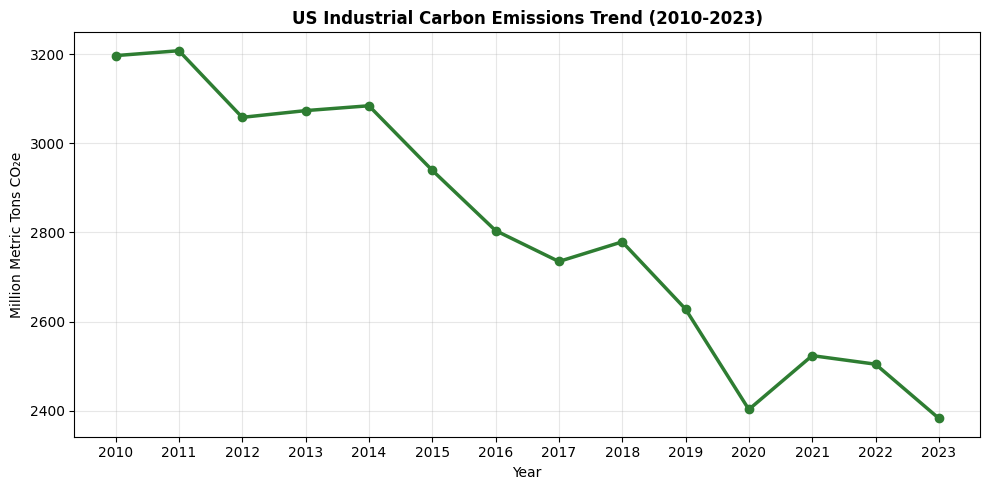

Chart 1: National Emissions Trend


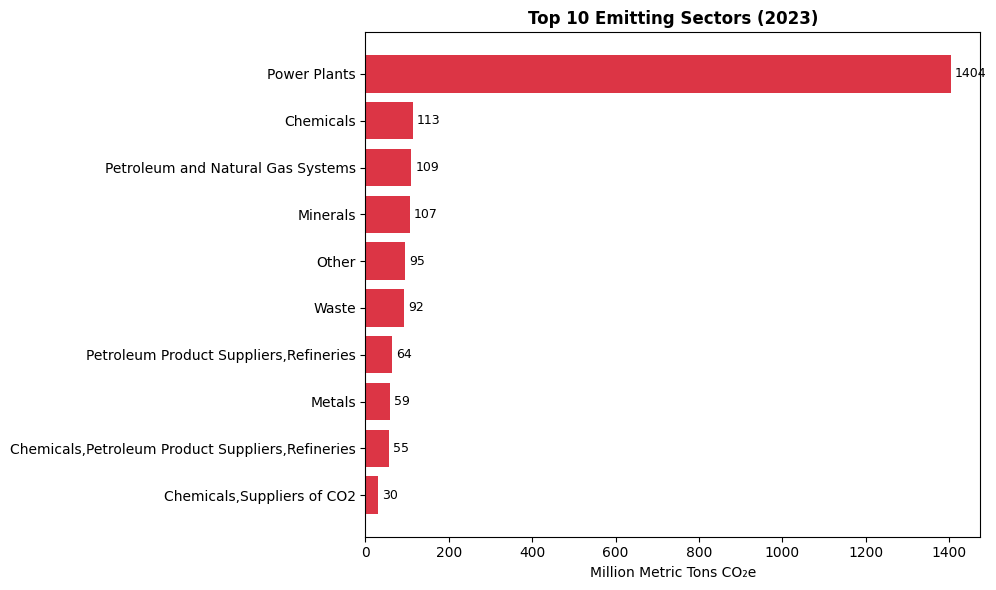

Chart 2: Top Sectors


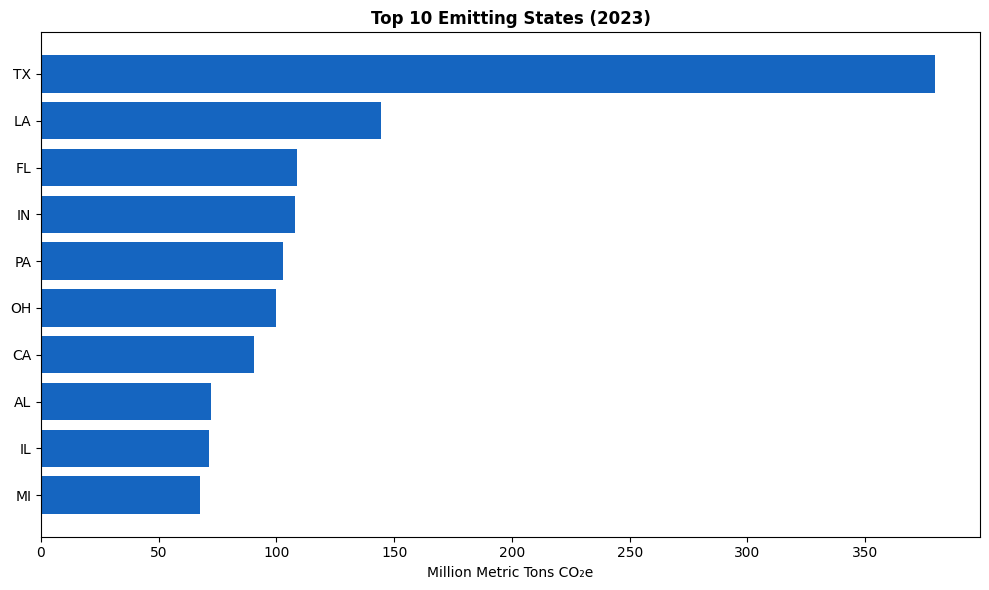

Chart 3: Top States


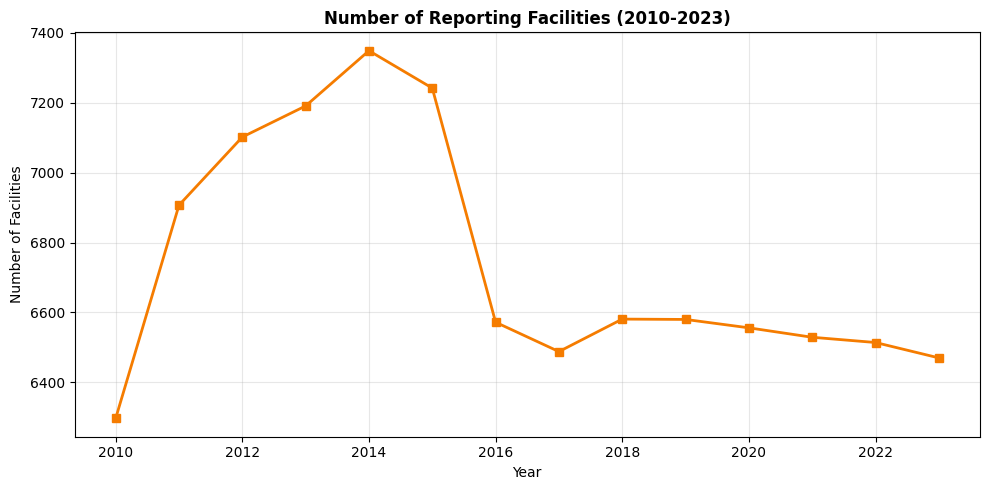

Chart 4: Facility Count


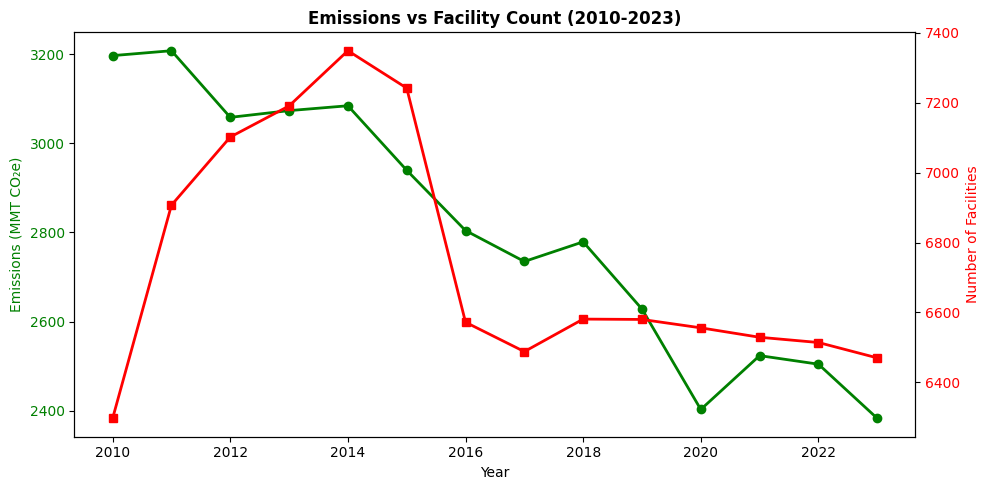

Chart 5: Emissions vs Facility Count

ALL CHARTS SAVED TO: /content/drive/MyDrive/EPA_GHGRP_Project/processed/charts


In [ ]:
# ============================================================
# SECTION 5: VISUALIZATION
# ============================================================

print(f"\n{'='*50}")
print(f"GENERATING CHARTS")
print(f"{'='*50}")

# --- Chart 1: National Emissions Trend ---
# Line chart showing the 14-year decline
plt.figure(figsize=(10, 5))
plt.plot(df_q1['reporting_year'], df_q1['total_emissions_mmt'],
         marker='o', color='#2E7D32', linewidth=2.5, markersize=6)
plt.title('US Industrial Carbon Emissions Trend (2010-2023)', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Million Metric Tons CO₂e')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHART_PATH}/01_national_trend.png', dpi=150, bbox_inches='tight')
plt.xticks(df_q1['reporting_year'])
plt.show()      # ← DISPLAY IN COLAB
plt.close()
print("Chart 1: National Emissions Trend")

# --- Chart 2: Top 10 Sectors ---
plt.figure(figsize=(10, 6))
sectors = df_q2.head(10)
plt.barh(sectors['industry_sector'], sectors['emissions_mmt'], color='#DC3545')
for i, value in enumerate(sectors['emissions_mmt']):
    plt.text(value + 10, i, f'{value:.0f}', va='center', fontsize=9)
plt.title('Top 10 Emitting Sectors (2023)', fontsize=12, fontweight='bold')
plt.xlabel('Million Metric Tons CO₂e')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{CHART_PATH}/02_top_sectors.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Chart 2: Top Sectors")

# --- Chart 3: Top 10 States ---
plt.figure(figsize=(10, 6))
states = df_q4.head(10)
plt.barh(states['state'], states['emissions_mmt'], color='#1565C0')
plt.title('Top 10 Emitting States (2023)', fontsize=12, fontweight='bold')
plt.xlabel('Million Metric Tons CO₂e')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{CHART_PATH}/03_top_states.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Chart 3: Top States")

# --- Chart 4: Facility Count Trend ---
# Shows how many facilities reported each year
plt.figure(figsize=(10, 5))
plt.plot(df_q1['reporting_year'], df_q1['num_facilities'],
         marker='s', color='#F57C00', linewidth=2, markersize=6)
plt.title('Number of Reporting Facilities (2010-2023)', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Facilities')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{CHART_PATH}/04_facility_count.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Chart 4: Facility Count")

# --- Chart 5: Dual Axis ---
# Compares emissions decline vs facility count decline on one chart
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df_q1['reporting_year'], df_q1['total_emissions_mmt'],
         'g-o', label='Emissions', linewidth=2)
ax1.set_xlabel('Year')
ax1.set_ylabel('Emissions (MMT CO₂e)', color='g')
ax1.tick_params(axis='y', labelcolor='g')

ax2 = ax1.twinx()
ax2.plot(df_q1['reporting_year'], df_q1['num_facilities'],
         'r-s', label='Facilities', linewidth=2)
ax2.set_ylabel('Number of Facilities', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Emissions vs Facility Count (2010-2023)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CHART_PATH}/05_emissions_vs_facilities.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Chart 5: Emissions vs Facility Count")

print(f"\n{'='*50}")
print(f"ALL CHARTS SAVED TO: {CHART_PATH}")
print(f"{'='*50}")

In [ ]:
# ============================================================
# SECTION 6: PROJECT SUMMARY
# ============================================================
# Final statistics and key findings for README and resume.

print(f"\n{'='*60}")
print(f"PROJECT COMPLETE")
print(f"{'='*60}")

print(f"\n📊 DATASET OVERVIEW")
print(f"  Source:        EPA Greenhouse Gas Reporting Program (GHGRP)")
print(f"  Period:        {df_clean['reporting_year'].min()} - {df_clean['reporting_year'].max()}")
print(f"  Total Records: {len(df_clean):,} facility-year rows")
print(f"  Facilities:    {df_clean['facility_id'].nunique():,} unique")
print(f"  States:        {df_clean['state'].nunique()}")

# ------------------------------------------------------------
# KEY FINDINGS
# ------------------------------------------------------------

print(f"\n🔍 KEY FINDINGS")

# 2010 vs 2023 emissions
emissions_2010 = df_q1.loc[
    df_q1['reporting_year'] == 2010,
    'total_emissions_mmt'
].iloc[0]

emissions_2023 = df_q1.loc[
    df_q1['reporting_year'] == 2023,
    'total_emissions_mmt'
].iloc[0]

pct_change = (
    (emissions_2023 - emissions_2010)
    / emissions_2010
) * 100

# 2022 vs 2023 national YoY
emissions_2022 = df_q1.loc[
    df_q1['reporting_year'] == 2022,
    'total_emissions_mmt'
].iloc[0]

yoy_2023 = (
    (emissions_2023 - emissions_2022)
    / emissions_2022
) * 100

# Top sector in 2023
top_sector = df_q2.iloc[0]['industry_sector']
top_sector_emissions = df_q2.iloc[0]['emissions_mmt']

# Top state in 2023
top_state = df_q4.iloc[0]['state']
top_state_emissions = df_q4.iloc[0]['emissions_mmt']

# Zero-emission records
zero_emission_records = (
    df_clean['emissions_flag'] == 'ZERO_REPORTED'
).sum()

print(
    f"  • National emissions declined "
    f"{abs(pct_change):.1f}% "
    f"({emissions_2010:.0f} → {emissions_2023:.0f} MMT)"
)

print(
    f"  • Top sector: "
    f"{top_sector} ({top_sector_emissions:.0f} MMT in 2023)"
)

print(
    f"  • Top state: "
    f"{top_state} ({top_state_emissions:.0f} MMT in 2023)"
)

print(
    f"  • YoY 2023: "
    f"{yoy_2023:.2f}% change from 2022"
)

print(
    f"  • Data flags: "
    f"{zero_emission_records:,} zero-emission records"
)

# ------------------------------------------------------------
# DELIVERABLES
# ------------------------------------------------------------

print(f"\n📁 DELIVERABLES CREATED")
print(f"  ✓ Cleaned CSV:      ghgp_cleaned_2010_2023.csv")
print(f"  ✓ SQLite Database:  emissions.db")
print(f"  ✓ SQL Queries:      5 analytical queries saved")
print(f"  ✓ Static Charts:    5 PNG images")
print(f"  ✓ Power BI Dashboard: Interactive 2010–2023 dashboard")

print(f"\n{'='*60}")
print(f"PROJECT COMPLETE")
print(f"{'='*60}")


PROJECT COMPLETE

📊 DATASET OVERVIEW
  Source:        EPA Greenhouse Gas Reporting Program (GHGRP)
  Period:        2010 - 2023
  Total Records: 94,378 facility-year rows
  Facilities:    8,778 unique
  States:        54

🔍 KEY FINDINGS
  • National emissions declined 25.5% (3197 → 2383 MMT)
  • Top sector: Power Plants (1404 MMT in 2023)
  • Top state: TX (380 MMT in 2023)
  • YoY 2023: -4.85% change from 2022
  • Data flags: 498 zero-emission records

📁 DELIVERABLES CREATED
  ✓ Cleaned CSV:      ghgp_cleaned_2010_2023.csv
  ✓ SQLite Database:  emissions.db
  ✓ SQL Queries:      5 analytical queries saved
  ✓ Static Charts:    5 PNG images
  ✓ Power BI Dashboard: Interactive 2010–2023 dashboard

PROJECT COMPLETE
